# Transfer Learning  

Dans cette partie, on s'attachera à l'élaboration d'un réseau de neuronnes par transfer learning, c'est à dire en utilisant un réseau de neuronnes pré-entraîné sur un problème similaire; ici, la reconnaissance d'images à partir d'une base de donnée étiquetée.

# Sommaire

- Importation des données
- Elaboration des datasets
- Elaboration du modèle de transfer learning
    - Modèle complet
    - Modèle avec dernière couche entraînable
    - Modèle avec plusieurs couches entraînables
    
    
# Import des données    

In [2]:
# Import des librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# import re
import tensorflow as tf
from tensorflow import keras
# from tensorflow.keras import layers

In [3]:
## Import des données brutes et analyse de leur architecture

path_folder = r'D:\Utilisateurs\Damien\Documents\Test_code\test_python\OCR_projets\IML\P6_\Archives' #
# path_cloud = 

# data = pd.read_csv(path_local + r'\QueryResults_2012.csv',sep=",",low_memory=False)

sub_path_image = '\\images' 

#path_img_folder = path_folder+ sub_path_image
path_img_folder = '/kaggle/input/dog-race-images/images'

directories_images = os.listdir( path_img_folder)
# directories_annotation = os.listdir(  )
# os.path.join()

# Elaboration des datasets

In [4]:
image_size = (224,224) #(180, 180)
batch_size = 32 # taille de collection
seed_state = 42 #1337 # random_state alias
num_classes = 120

In [5]:
# ds_full = tf.keras.preprocessing.image_dataset_from_directory( # tensorflow v2.3
#     directory = path_img_folder,
#     validation_split=0,
#     seed=seed_state,
#     image_size=image_size,
#     batch_size=batch_size,
# )

ds_full = tf.keras.utils.image_dataset_from_directory( # tensorflow v2.9
    directory = path_img_folder,
    seed=seed_state,
    image_size=image_size,
    batch_size=batch_size,
    label_mode = "categorical" #necessaire pour avoir la taille de la classe de catégorisation dans les dataset.take()
)



Found 20580 files belonging to 120 classes.


2022-07-17 17:16:50.423552: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [6]:
ds_size =  ds_full.cardinality().numpy() # len(list_x_path)/batch_size
train_size = int(0.8 * ds_size)
val_size = int(0.1 * ds_size)

In [7]:
ds_train = ds_full.take(train_size)    
ds_val = ds_full.skip(train_size).take(val_size)
ds_test = ds_full.skip(train_size).skip(val_size)

In [8]:
ds_train = ds_train.prefetch(buffer_size=batch_size)
ds_val = ds_val.prefetch(buffer_size=batch_size)
ds_test = ds_test.prefetch(buffer_size=batch_size)

# Elaboration du modèle de transfer learning  
#### Data augmentation

In [9]:
from tensorflow.keras import layers
# from tensorfloww.python import trackable

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        #layers.RandomContrast(0.5), #Altère l'image de façon trop prononcée et irréaliste
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
    ]
)

2022-07-17 17:16:51.183471: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


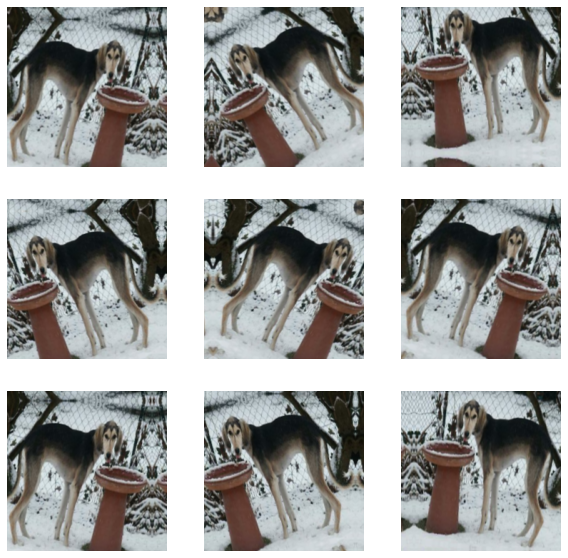

In [10]:
plt.figure(figsize=(10, 10))
for images, _ in ds_train.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

## Modèle complet

In [11]:
#from tensorflow.keras.applications import EfficientNetB0
#model = EfficientNetB0(include_top=True, weights="../input/efnetb0/efficientnetb0.h5") #tf.keras.applications.efficientnet.
#model.trainable = False
#model.output

In [12]:
#model.summary()

In [13]:
# model.layers[-1].output

## Modèle avec dernière couche entraînable

In [14]:
from tensorflow.keras.applications import EfficientNetB0
# import efficientnet.keras as efn 

#with strategy.scope():
def make_model_NetB0(IMG_SIZE, num_classes, augmentation_setup, top_dropout_rate, lr):
    
    
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Image augmentation block
    if augmentation_setup == 1:
        x = data_augmentation(inputs)
    else:
        x = inputs
    
    model = EfficientNetB0(include_top=True ,input_tensor=x,  weights="../input/efnetb0/efficientnetb0.h5") #tf.keras.applications.efficientnet.
    #model = EfficientNetB1(include_top=False, weights="imagenet", classes=num_classes)(x)
    
    
    # Freeze the pretrained weights
    model.trainable = False
    x = model.layers[-2].output
    
    # Rebuild top
    #x = layers.GlobalAveragePooling2D(name="avg_pool")(x) #on 
    #x = layers.BatchNormalization()(x)

    x = layers.Dropout(top_dropout_rate)(x)
    
    outputs = layers.Dense(num_classes,"softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model

#### Paramètres du modèle

In [15]:
IMG_SIZE = 224
num_classes = 120
augmentation_setup = 1
top_dropout_rate = 0.2 # 0.2 model_2 # 0.5 model_1 ## Le réseau étant conséquent, on peut se permettre d'attribuer un facteur de dropout_rate assez élevé
lr = 1e-3

epochs = 50 

#### Construction du modèle

In [16]:
model_NetB0 = make_model_NetB0(IMG_SIZE, num_classes, augmentation_setup, top_dropout_rate, lr)
model_NetB0.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
sequential (Sequential)         (None, 224, 224, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
rescaling (Rescaling)           (None, 224, 224, 3)  0           sequential[0][0]                 
__________________________________________________________________________________________________
normalization (Normalization)   (None, 224, 224, 3)  7           rescaling[0][0]                  
______________________________________________________________________________________________

#### Entrainement et visualisation

In [17]:
# hist = model_NetB0.fit(ds_train, epochs=epochs, validation_data=ds_val, verbose = 2)

In [18]:
import matplotlib.pyplot as plt

def plot_hist(hist):
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history["val_accuracy"])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(["train", "validation"], loc="upper left")
    plt.show()


# plot_hist(hist)

## Modèle avec plusieurs couches entraînables  
On décide dans ce cas de permettre à plusieurs couches terminales du modèles chargé efficientnet d'être entraînables, de sorte à obtenir un modèle qui soit encore plus spécialisé à reconnaître les images de notre dataset constitué de races de chiens, et voir si l'on obtient de meilleures performances. On va donc élaborer une nouvelle fonction d'élaboration de modèles.

In [19]:
from tensorflow.keras.applications import EfficientNetB0
# import efficientnet.keras as efn 

#with strategy.scope():
def make_model_NetB0_trainable(IMG_SIZE, num_classes, augmentation_setup, top_dropout_rate, lr, n_train_layer):
    
    
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Image augmentation block
    if augmentation_setup == 1:
        x = data_augmentation(inputs)
    else:
        x = inputs
    
    model = EfficientNetB0(include_top=True ,input_tensor=x,  weights="../input/efnetb0/efficientnetb0.h5") #tf.keras.applications.efficientnet.
    #model = EfficientNetB1(include_top=False, weights="imagenet", classes=num_classes)(x)
    

    
    # Freeze the pretrained weights
    model.trainable = False
    x = model.layers[-2].output
    
    # Rebuild top
    #x = layers.GlobalAveragePooling2D(name="avg_pool")(x) #on 
    #x = layers.BatchNormalization()(x)

    x = layers.Dropout(top_dropout_rate)(x)
    
    outputs = layers.Dense(num_classes,"softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    
    for layer in model.layers[-n_train_layer:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model

#### Construction du modèle

In [20]:
model_NetB0_trainable = make_model_NetB0_trainable(IMG_SIZE, num_classes, augmentation_setup, top_dropout_rate, lr, 10) # On prends une valeur de n_layer_trainable par défaut, mais pas trop grande pour réaliser l'entraînement sans encombre
model_NetB0_trainable.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
sequential (Sequential)         (None, 224, 224, 3)  0           input_2[0][0]                    
__________________________________________________________________________________________________
rescaling_1 (Rescaling)         (None, 224, 224, 3)  0           sequential[1][0]                 
__________________________________________________________________________________________________
normalization_1 (Normalization) (None, 224, 224, 3)  7           rescaling_1[0][0]                
____________________________________________________________________________________________

#### Entrainement et visualisation

In [21]:
hist_train = model_NetB0_trainable.fit(ds_train, epochs=epochs, validation_data=ds_val, verbose=2)

Epoch 1/50


Cleanup called...


515/515 - 456s - loss: 1.5843 - accuracy: 0.5607 - val_loss: 0.7510 - val_accuracy: 0.7705
Epoch 2/50


Cleanup called...


515/515 - 445s - loss: 1.0154 - accuracy: 0.6893 - val_loss: 0.7523 - val_accuracy: 0.7773
Epoch 3/50


...

515/515 - 440s - loss: 0.2673 - accuracy: 0.9191 - val_loss: 1.3110 - val_accuracy: 0.7690
Epoch 49/50


Cleanup called...


515/515 - 440s - loss: 0.2624 - accuracy: 0.9174 - val_loss: 1.2074 - val_accuracy: 0.7856
Epoch 50/50


Cleanup called...


515/515 - 439s - loss: 0.2562 - accuracy: 0.9244 - val_loss: 1.2664 - val_accuracy: 0.7720


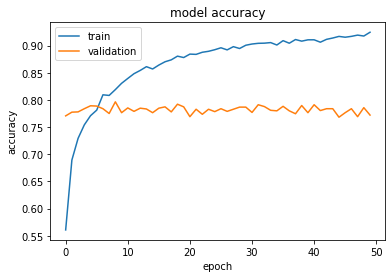

In [22]:
import matplotlib.pyplot as plt
plot_hist(hist_train)

#### Sauvegarde

In [23]:
import joblib

joblib.dump(hist_train.history, 'hist_train_NetB0_2' + '.joblib')
model_NetB0_trainable.save('model_NetB0_train_2')

2022-07-17 23:32:34.015740: W tensorflow/python/util/util.cc:348] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.
/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)
